In [271]:
# Customer Personality Analysis - Unsupervised Learning Tugas 3


import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset

In [272]:
#

df = pd.read_csv('cpa.csv',sep=r"\t",engine="python")
print(df.columns)
df.set_index("ID",inplace=True)
df.sort_index(inplace=True)
df.head()

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,
0,1985,Graduation,Married,70951.0,0,0,04-05-2013,66,239,10,...,1,0,0,0,0,0,0,3,11,0
1,1961,Graduation,Single,57091.0,0,0,15-06-2014,0,464,5,...,5,0,0,0,0,1,0,3,11,1
9,1975,Master,Single,46098.0,1,1,18-08-2012,86,57,0,...,8,0,0,0,0,0,0,3,11,0
13,1947,PhD,Widow,25358.0,0,1,22-07-2013,57,19,0,...,6,0,0,0,0,0,0,3,11,0
17,1971,PhD,Married,60491.0,0,1,06-09-2013,81,637,47,...,5,0,0,0,0,0,0,3,11,0


#Step2: lakukan Eksplorasi awal

In [294]:
df.columns = df.columns.str.strip().str.lower()
    
df1 = df.copy()
for c in df1.select_dtypes(["object"]).columns:
    if c == "dt_customer":
        df1[c] = pd.to_datetime(df1[c],format="%d-%m-%Y")
    else:
        df1[c] = df1[c].str.lower().str.replace(' ','_')
for c in df1.columns:
    print(f" before {c} {df1[c].unique()}\n")
stausMap = {
    "widow" : "single",
    "divorced" : "single",
    "alone" : "single",
    "absurd" : "single",
    "yolo" : "single",
    "together" : "married"
}
edMap = {
    "graduation" : "undergraduate",
    "master" : "graduate",
    "phd" : "postgraduate",
    "2n_cycle" : "graduate"
}
df1["marital_status"] = df1["marital_status"].replace(stausMap)
df1["education"] = df1["education"].replace(edMap).str.lower()
for c in df1.columns:
    print(f"{c} {df1[c].unique()}\n")

df1.info()

withOutlier = ['income','year_birth']
for c in withOutlier:
    mult = (1.5 if c == "year_birth" else 2)
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1


    lower_bound = Q1 - mult * IQR
    upper_bound = Q3 + mult * IQR

    df1 = df1[(df1[c] >= lower_bound) & (df1[c] <= upper_bound)]

df1

 before year_birth [1985 1961 1975 1947 1971 1965 1976 1960 1958 1987 1964 1970 1963 1972
 1953 1982 1969 1981 1988 1951 1966 1945 1977 1986 1980 1956 1946 1996
 1962 1948 1955 1979 1967 1952 1959 1973 1989 1968 1978 1957 1950 1974
 1954 1944 1991 1984 1949 1983 1992 1899 1943 1990 1993 1995 1994 1940
 1941 1900 1893]

 before education ['graduation' 'master' 'phd' '2n_cycle' 'basic']

 before marital_status ['married' 'single' 'widow' 'divorced' 'together' 'alone' 'yolo' 'absurd']

 before income [ 70951.  57091.  46098. ... 156924.  26487.  41411.]

 before kidhome [0 1 2]

 before teenhome [0 1 2]

 before dt_customer <DatetimeArray>
['2013-05-04 00:00:00', '2014-06-15 00:00:00', '2012-08-18 00:00:00',
 '2013-07-22 00:00:00', '2013-09-06 00:00:00', '2013-09-01 00:00:00',
 '2012-12-03 00:00:00', '2014-02-15 00:00:00', '2012-11-16 00:00:00',
 '2012-09-08 00:00:00',
 ...
 '2013-10-05 00:00:00', '2014-02-03 00:00:00', '2013-11-08 00:00:00',
 '2014-05-05 00:00:00', '2012-08-05 00:00:00',

,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,...,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,z_costcontact,z_revenue,response
ID,,,,,,,,,,,,,,,,,,,,,
0,1985,undergraduate,married,70951.0,0,0,2013-05-04,66,239,10,...,1,0,0,0,0,0,0,3,11,0
1,1961,undergraduate,single,57091.0,0,0,2014-06-15,0,464,5,...,5,0,0,0,0,1,0,3,11,1
9,1975,graduate,single,46098.0,1,1,2012-08-18,86,57,0,...,8,0,0,0,0,0,0,3,11,0
13,1947,postgraduate,single,25358.0,0,1,2013-07-22,57,19,0,...,6,0,0,0,0,0,0,3,11,0
17,1971,postgraduate,married,60491.0,0,1,2013-09-06,81,637,47,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11176,1970,postgraduate,married,65968.0,0,1,2014-05-12,12,376,9,...,3,0,0,0,0,0,0,3,11,0
11178,1972,graduate,single,42394.0,1,0,2014-03-23,69,15,2,...,7,0,0,0,0,0,0,3,11,0
11187,1978,basic,single,26487.0,1,0,2013-05-20,23,2,8,...,5,0,0,0,0,0,0,3,11,0


# Step 3: Identifikasi kolom numerik & kategori

In [295]:
colKategori = []
colNumeric = []

for col in df1.select_dtypes(include=["object","datetime"]).columns:
    colKategori.append(col)

for col in df1.select_dtypes(include=["number"]).columns:
    if col in ["z_costcontact" , "z_revenue"]:
        continue
    unique_vals = sorted(df1[col].dropna().drop_duplicates().unique())

    if len(unique_vals) > 2:
        #diff >= 1
        diff = all(
            (unique_vals[i + 1] - unique_vals[i]) >= 1
            for i in range(len(unique_vals) - 1)
        )
        if diff:
            colNumeric.append(col)
    else :
        colKategori.append(col)
print(f"Numeric : {colNumeric}")
print(f"Kategory : {colKategori}")
df1.info()



Numeric : ['year_birth', 'income', 'kidhome', 'teenhome', 'recency', 'mntwines', 'mntfruits', 'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts', 'mntgoldprods', 'numdealspurchases', 'numwebpurchases', 'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth']
Kategory : ['education', 'marital_status', 'dt_customer', 'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1', 'acceptedcmp2', 'complain', 'response']
<class 'pandas.core.frame.DataFrame'>
Index: 2205 entries, 0 to 11191
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   year_birth           2205 non-null   int64         
 1   education            2205 non-null   object        
 2   marital_status       2205 non-null   object        
 3   income               2205 non-null   float64       
 4   kidhome              2205 non-null   int64         
 5   teenhome             2205 non-null   int64         
 6   d

# Step 4: Imputasi missing value

year_birth             0
income                 0
kidhome                0
teenhome               0
recency                0
mntwines               0
mntfruits              0
mntmeatproducts        0
mntfishproducts        0
mntsweetproducts       0
mntgoldprods           0
numdealspurchases      0
numwebpurchases        0
numcatalogpurchases    0
numstorepurchases      0
numwebvisitsmonth      0
dtype: int64


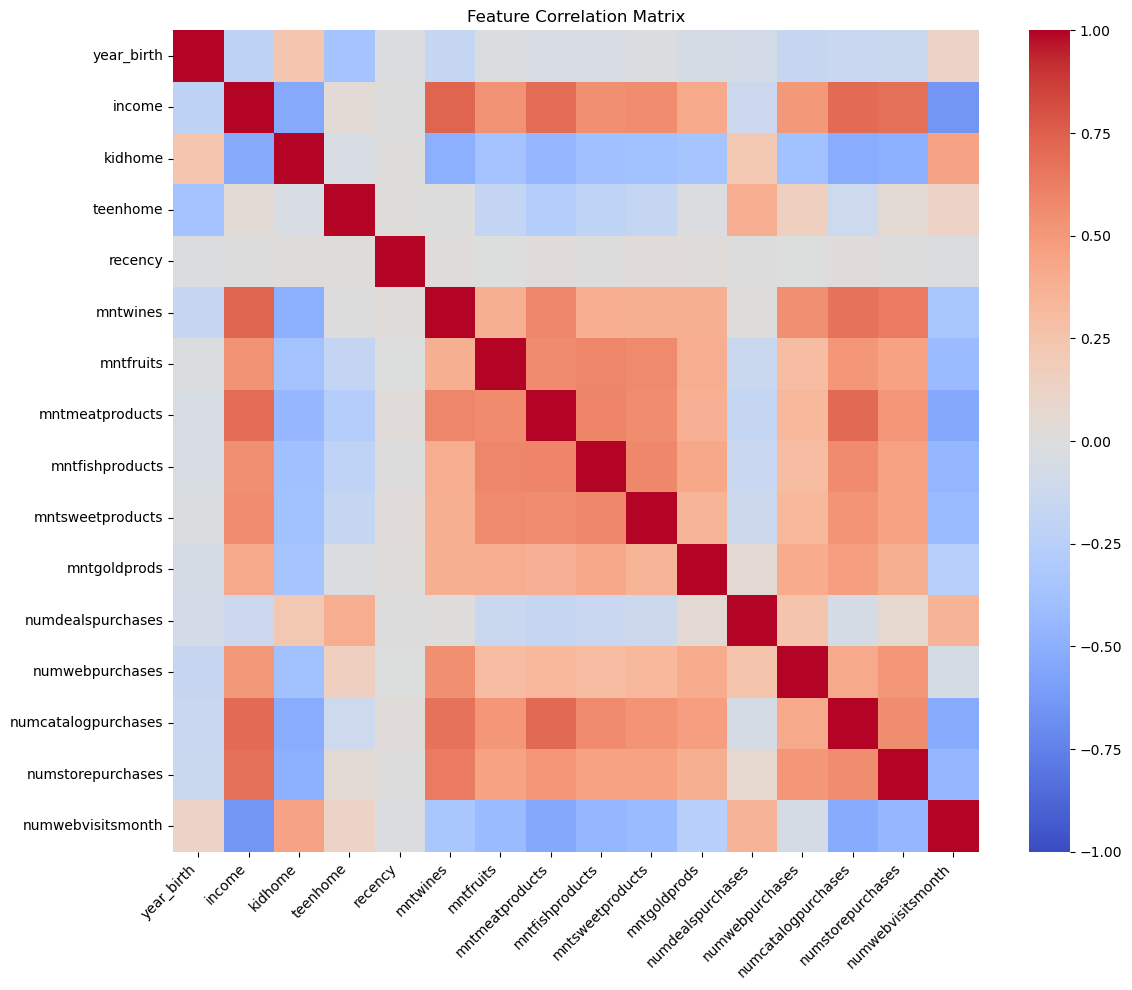

['mntwines', 'numcatalogpurchases', 'mntmeatproducts', 'numstorepurchases', 'mntsweetproducts', 'mntfishproducts', 'mntfruits', 'numwebpurchases', 'mntgoldprods']
group mean ID
0        70951.0
1        57091.0
9        46098.0
13       25358.0
17       60491.0
          ...   
11176    65968.0
11178    42394.0
11187    26487.0
11188    26091.0
11191    41411.0
Name: income, Length: 2205, dtype: float64
year_birth             0
income                 0
kidhome                0
teenhome               0
recency                0
mntwines               0
mntfruits              0
mntmeatproducts        0
mntfishproducts        0
mntsweetproducts       0
mntgoldprods           0
numdealspurchases      0
numwebpurchases        0
numcatalogpurchases    0
numstorepurchases      0
numwebvisitsmonth      0
dtype: int64


,year_birth,income,kidhome,teenhome,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000
mean,1968.904308,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,2.318367,4.100680,2.645351,5.823583,5.336961
std,11.705801,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,1.886107,2.737424,2.798647,3.241796,2.413535
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000
50%,1970.000000,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,2.000000,4.000000,2.000000,5.000000,6.000000
75%,1977.000000,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000
max,1996.000000,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000


In [296]:
dfNumeric = df1[colNumeric].copy()
print(dfNumeric.isna().sum())
corrMatrix = dfNumeric.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corrMatrix, annot=False, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

targetScore = 0.3
incomeCorr = corrMatrix["income"]
filteredIncomeCorr = incomeCorr[(incomeCorr > targetScore) & (incomeCorr < 1.0)]
incomeCorrList = list(filteredIncomeCorr.sort_values(ascending=False).index)
originalIncomeMean = dfNumeric["income"].mean()

print(incomeCorrList)

group_means = dfNumeric.groupby(incomeCorrList)[
    "income"
].transform("mean")

print(f"group mean {group_means}")

dfNumeric["income"] = dfNumeric["income"].fillna(group_means)
dfNumeric["income"] = dfNumeric["income"].fillna(originalIncomeMean)

print(dfNumeric.isna().sum())
dfNumeric.describe()


# Step 5: Encoding fitur kategori

In [298]:
dfKategori = df1[colKategori].copy()

dfKategori["day"] = dfKategori["dt_customer"].dt.day
dfKategori["month"] = dfKategori["dt_customer"].dt.month
dfKategori["year"] = dfKategori["dt_customer"].dt.year
encoder = OneHotEncoder(dtype=int,sparse_output=False)
encoded_data = encoder.fit_transform(dfKategori[["education","marital_status"]])
encodedDf = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(["education","marital_status"]),
    index=dfKategori.index
) 
dfKategori = dfKategori.drop(["education","marital_status","dt_customer"],axis=1)
dfKategoriencoded = pd.concat([dfKategori, encodedDf], axis=1)
dfKategoriencoded.info()
dfKategoriencoded

<class 'pandas.core.frame.DataFrame'>
Index: 2205 entries, 0 to 11191
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   acceptedcmp3             2205 non-null   int64
 1   acceptedcmp4             2205 non-null   int64
 2   acceptedcmp5             2205 non-null   int64
 3   acceptedcmp1             2205 non-null   int64
 4   acceptedcmp2             2205 non-null   int64
 5   complain                 2205 non-null   int64
 6   response                 2205 non-null   int64
 7   day                      2205 non-null   int32
 8   month                    2205 non-null   int32
 9   year                     2205 non-null   int32
 10  education_basic          2205 non-null   int64
 11  education_graduate       2205 non-null   int64
 12  education_postgraduate   2205 non-null   int64
 13  education_undergraduate  2205 non-null   int64
 14  marital_status_married   2205 non-null   int64
 15  marital_

,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,day,month,year,education_basic,education_graduate,education_postgraduate,education_undergraduate,marital_status_married,marital_status_single
ID,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,4,5,2013,0,0,0,1,1,0
1,0,0,0,0,1,0,1,15,6,2014,0,0,0,1,0,1
9,0,0,0,0,0,0,0,18,8,2012,0,1,0,0,0,1
13,0,0,0,0,0,0,0,22,7,2013,0,0,1,0,0,1
17,0,0,0,0,0,0,0,6,9,2013,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11176,0,0,0,0,0,0,0,12,5,2014,0,0,1,0,1,0
11178,0,0,0,0,0,0,0,23,3,2014,0,1,0,0,0,1
11187,0,0,0,0,0,0,0,20,5,2013,1,0,0,0,0,1


#Gabungkan data numerik & hasil encoding

In [299]:
dffinal = pd.concat([dfKategoriencoded, dfNumeric], axis=1)
dffinal.info()
dffinal

<class 'pandas.core.frame.DataFrame'>
Index: 2205 entries, 0 to 11191
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   acceptedcmp3             2205 non-null   int64  
 1   acceptedcmp4             2205 non-null   int64  
 2   acceptedcmp5             2205 non-null   int64  
 3   acceptedcmp1             2205 non-null   int64  
 4   acceptedcmp2             2205 non-null   int64  
 5   complain                 2205 non-null   int64  
 6   response                 2205 non-null   int64  
 7   day                      2205 non-null   int32  
 8   month                    2205 non-null   int32  
 9   year                     2205 non-null   int32  
 10  education_basic          2205 non-null   int64  
 11  education_graduate       2205 non-null   int64  
 12  education_postgraduate   2205 non-null   int64  
 13  education_undergraduate  2205 non-null   int64  
 14  marital_status_married   220

,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,day,month,year,...,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth
ID,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,4,5,2013,...,10,554,254,87,54,1,3,4,9,1
1,0,0,0,0,1,0,1,15,6,2014,...,5,64,7,0,37,1,7,3,7,5
9,0,0,0,0,0,0,0,18,8,2012,...,0,27,0,0,36,4,3,2,2,8
13,0,0,0,0,0,0,0,22,7,2013,...,0,5,0,0,8,2,1,0,3,6
17,0,0,0,0,0,0,0,6,9,2013,...,47,237,12,19,76,4,6,11,7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11176,0,0,0,0,0,0,0,12,5,2014,...,9,83,19,4,4,2,5,4,7,3
11178,0,0,0,0,0,0,0,23,3,2014,...,2,10,0,1,4,1,1,0,3,7
11187,0,0,0,0,0,0,0,20,5,2013,...,8,10,12,14,23,3,2,1,3,5


# Step 6: Scaling data

In [300]:
scaler = StandardScaler()
dfScaled = scaler.fit_transform(dffinal)


# Step 7: Tentukan jumlah cluster optimal (Elbow + Silhouette)

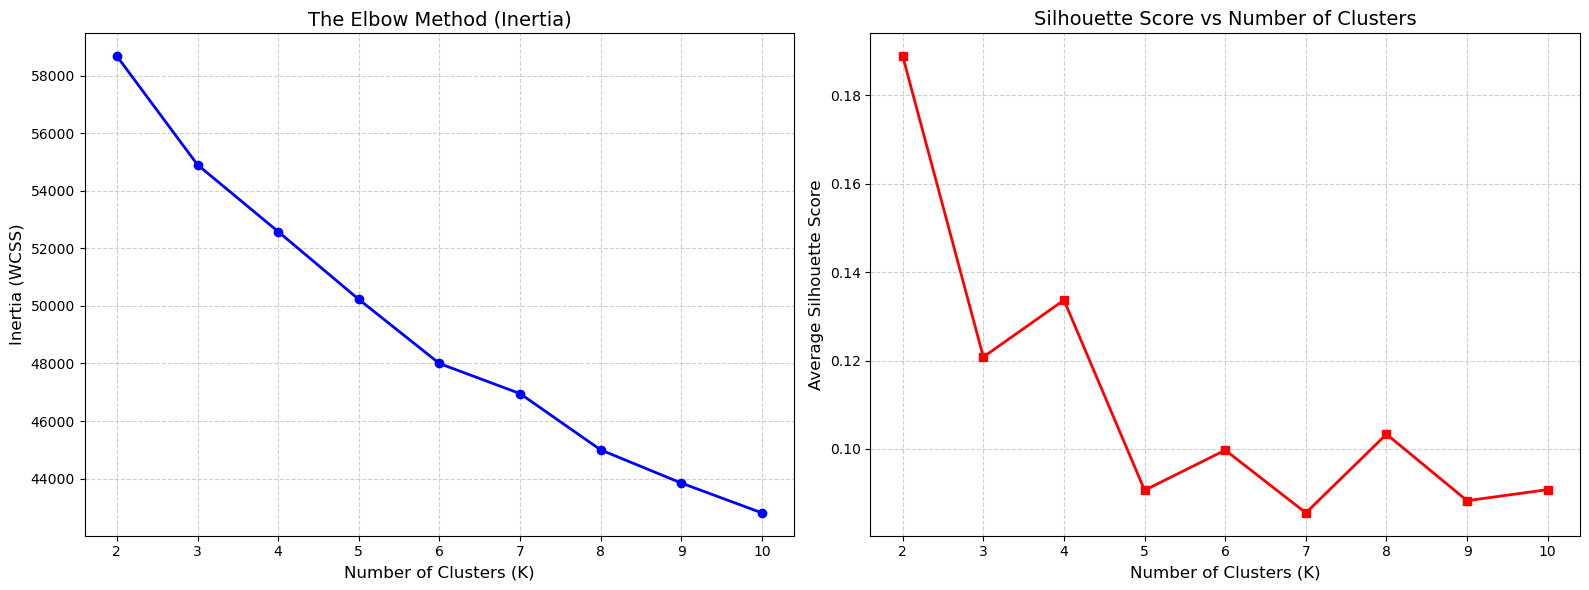

In [301]:
clusterRange = range(2, 11) 

inertiaScores = []
silhouetteScores = []
for k in clusterRange:
    
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(dfScaled)


    inertiaScores.append(kmeans.inertia_)

    labels = kmeans.labels_
    score = silhouette_score(dfScaled, labels)
    silhouetteScores.append(score)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].plot(clusterRange, inertiaScores, marker="o", color="b", linewidth=2)
ax[0].set_title("The Elbow Method (Inertia)", fontsize=14)
ax[0].set_xlabel("Number of Clusters (K)", fontsize=12)
ax[0].set_ylabel("Inertia (WCSS)", fontsize=12)
ax[0].set_xticks(clusterRange)
ax[0].grid(True, linestyle="--", alpha=0.6)

ax[1].plot(clusterRange, silhouetteScores, marker="s", color="r", linewidth=2)
ax[1].set_title("Silhouette Score vs Number of Clusters", fontsize=14)
ax[1].set_xlabel("Number of Clusters (K)", fontsize=12)
ax[1].set_ylabel("Average Silhouette Score", fontsize=12)
ax[1].set_xticks(clusterRange)
ax[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Step 8: Pilih k optimal dan klasterisasi

In [339]:
kOptimal = 3
finalKmean = KMeans(
    n_clusters=kOptimal, init="k-means++",random_state=42,n_init=10
)
clusterLabel = finalKmean.fit_predict(dfScaled)
dffinal["cluster"] = clusterLabel

cluster_profile = dffinal.groupby("cluster").mean(numeric_only=True)
print(cluster_profile.T)


cluster                             0             1             2
acceptedcmp3                 0.075490      0.085821      0.061633
acceptedcmp4                 0.007843      0.130597      0.132512
acceptedcmp5                 0.000000      0.283582      0.013867
acceptedcmp1                 0.000980      0.229478      0.027735
acceptedcmp2                 0.001961      0.035448      0.013867
complain                     0.011765      0.003731      0.009245
response                     0.095098      0.307836      0.109399
day                         15.790196     15.248134     15.810478
month                        6.247059      6.365672      6.898305
year                      2013.131373   2013.039179   2012.855162
education_basic              0.051961      0.000000      0.001541
education_graduate           0.275490      0.236940      0.237288
education_postgraduate       0.185294      0.192164      0.283513
education_undergraduate      0.487255      0.570896      0.477658
marital_st

# Step 9: Visualisasi klaster dengan PCA 2D

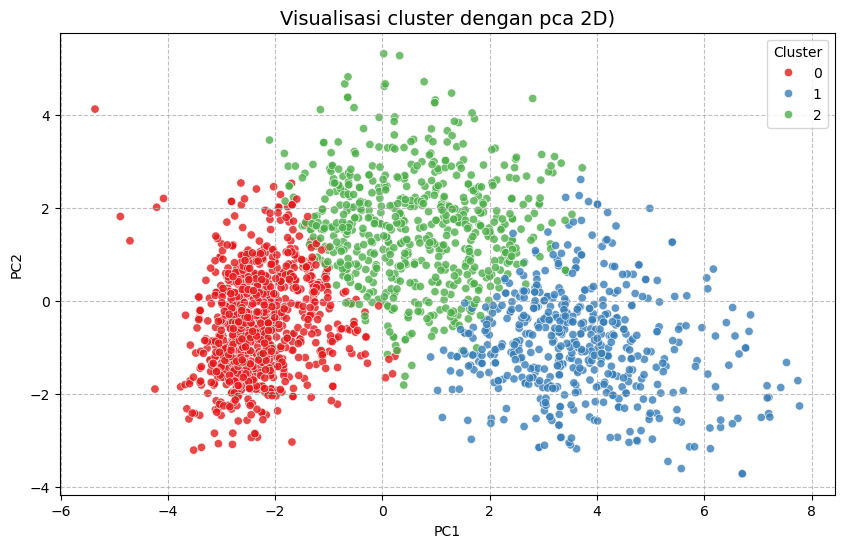

In [329]:
pca = PCA(n_components=2)
pcaFeature = pca.fit_transform(dfScaled)

dfPca = pd.DataFrame(data=pcaFeature,columns=["PC1","PC2"])
dfPca["cluster"] = dffinal["cluster"].reset_index(drop=True)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=dfPca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    alpha=0.8
)
plt.title(f"Visualisasi cluster dengan pca 2D)", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.grid(True,linestyle="--",alpha=0.8)
plt.show()

# Step 10: Profiling cluster (rata-rata fitur per cluster)

cluster
0    1020
2     649
1     536
Name: count, dtype: int64
Means per cluster:
         acceptedcmp3  acceptedcmp4  acceptedcmp5  acceptedcmp1  acceptedcmp2  complain  response        day     month         year  education_basic  education_graduate  education_postgraduate  education_undergraduate  marital_status_married  marital_status_single   year_birth        income   kidhome  teenhome    recency    mntwines  mntfruits  mntmeatproducts  mntfishproducts  mntsweetproducts  mntgoldprods  numdealspurchases  numwebpurchases  numcatalogpurchases  numstorepurchases  numwebvisitsmonth
cluster                                                                                                                                                                                                                                                                                                                                                                                                                   

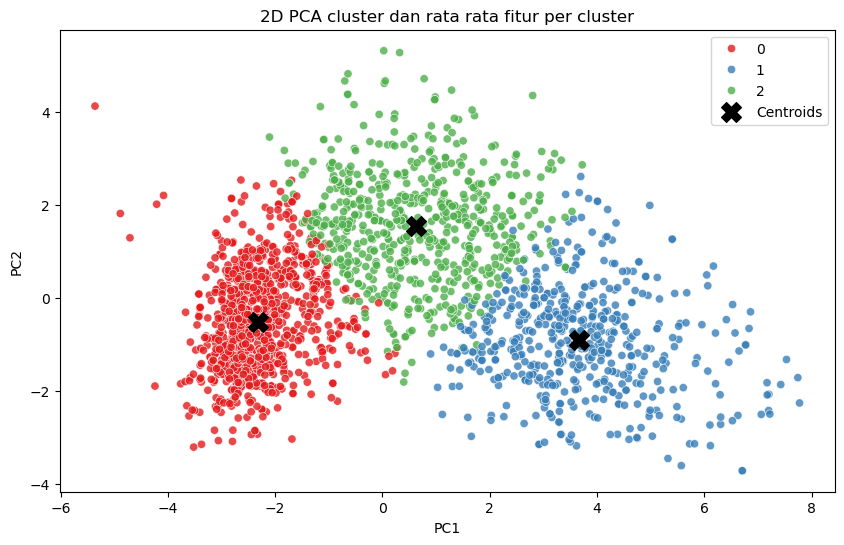

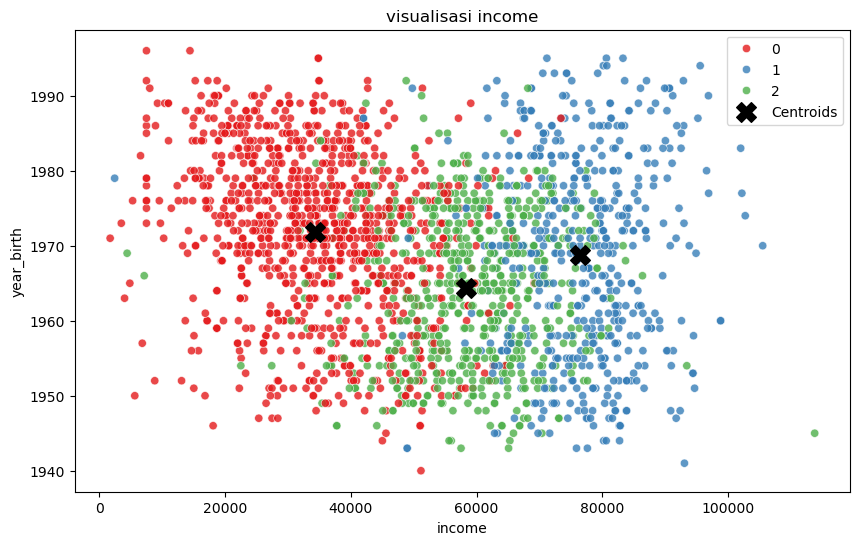

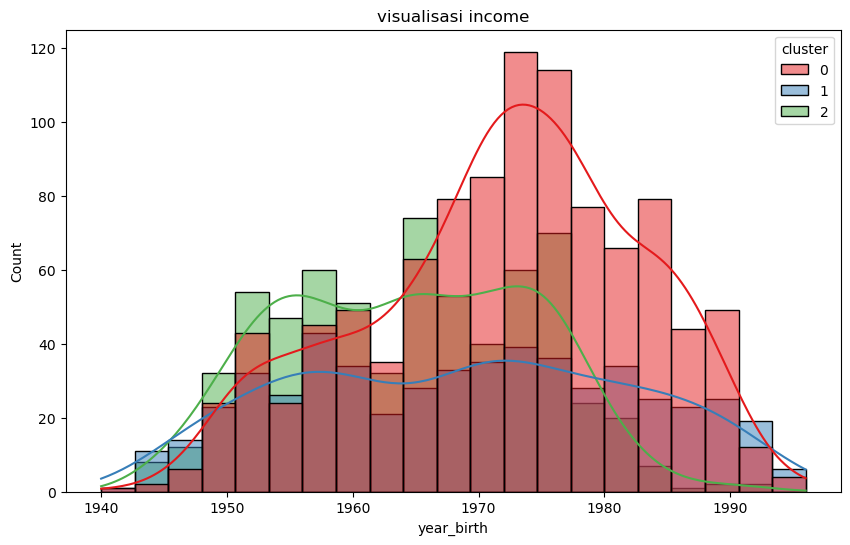

In [357]:

print(dffinal["cluster"].value_counts())
clusterMean = dffinal.groupby('cluster').mean()
print("Means per cluster:")
print(f"{clusterMean.to_string()}")

clusterProfile_2d = dfPca.groupby('cluster').mean()
print("2D Means per cluster:")
print(clusterProfile_2d)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=dfPca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    alpha=0.8
)
centroids = clusterProfile_2d[['PC1', 'PC2']].values
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', label='Centroids')

plt.title('2D PCA cluster dan rata rata fitur per cluster')
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=dffinal,
    x="income",
    y="year_birth",
    hue="cluster",
    palette="Set1",
    alpha=0.8
)
centroids = clusterMean[['income', 'year_birth']].values
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', label='Centroids')
plt.title('visualisasi income')
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(
    data=dffinal,
    x="year_birth",
    hue="cluster",
    palette="Set1",
    alpha=0.5,
    kde=True
)
plt.title('visualisasi income')
plt.show()


# Simpulkan Analisa dari hasil